# Llibreries

In [2]:
import pandas as pd
import numpy as np
import json
import os
import sys
from pathlib import Path

# Visualització
import matplotlib.pyplot as plt
import seaborn as sns

# Config vis
sns.set_theme()

# Funcions
cwd = os.getcwd()
parent = os.path.abspath(os.path.join(cwd, os.pardir))
sys.path.insert(0, parent)
from src.utils import neteja_noms_columnes

# Dimensions
Carrega del dataset que conté totes les dimensions de les dades

In [38]:
dim_barris = pd.read_csv("../data/dimensions/BarcelonaCiutat_Barris.csv")
dim_barris.head()

,codi_districte,nom_districte,codi_barri,nom_barri,geometria_etrs89,geometria_wgs84
0,1,Ciutat Vella,1,el Raval,"POLYGON ((430162.1875 4581936.9845, 430102.838...","POLYGON ((2.16471378585589 41.3859301967194, 2..."
1,1,Ciutat Vella,2,el Barri Gòtic,"POLYGON ((431189.9075 4581851.4475, 431025.789...","POLYGON ((2.1770141884741 41.385248355328, 2.1..."
2,1,Ciutat Vella,3,la Barceloneta,"POLYGON ((432798.7341255 4582081.2599495, 4327...","POLYGON ((2.19622882469513 41.387454220446, 2...."
3,1,Ciutat Vella,4,"Sant Pere, Santa Caterina i la Ribera","POLYGON ((431733.736 4582441.816, 431557.5115 ...","POLYGON ((2.18345134701381 41.3906119681235, 2..."
4,2,Eixample,5,el Fort Pienc,"POLYGON ((431741.8152 4582625.6491, 432012.183...","POLYGON ((2.18352725722411 41.3922683849226, 2..."


# Dades econòmiques
En aquest apartat, obtindrem dades econòmiques dels barris.

## Renda

### 2023

In [3]:
df_renda_23_raw = pd.read_csv("../data/raw/renda/2023_renda_neta_mitjana_per_persona.csv")
df_renda_23_raw.head()

,Any,Codi_Districte,Nom_Districte,Codi_Barri,Nom_Barri,Seccio_Censal,Import_Euros
0,2023,1,Ciutat Vella,1,el Raval,1,13122
1,2023,1,Ciutat Vella,1,el Raval,2,10966
2,2023,1,Ciutat Vella,1,el Raval,3,10702
3,2023,1,Ciutat Vella,1,el Raval,4,12988
4,2023,1,Ciutat Vella,1,el Raval,5,11323


In [4]:
df_renda_23_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Any             1068 non-null   int64 
 1   Codi_Districte  1068 non-null   int64 
 2   Nom_Districte   1068 non-null   object
 3   Codi_Barri      1068 non-null   int64 
 4   Nom_Barri       1068 non-null   object
 5   Seccio_Censal   1068 non-null   int64 
 6   Import_Euros    1068 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 58.5+ KB


**Observacions:**
- No es detecten valors nuls i la variable Import_Euros, està correcte (int64)

In [5]:
# Agrupem per barri i calculem la mitjana
df_renda_23_grouped = df_renda_23_raw.groupby("Codi_Barri").agg({"Import_Euros": "mean"}).reset_index()
df_renda_23_grouped.head()

,Codi_Barri,Import_Euros
0,1,11917.476190
1,2,16013.222222
2,3,15359.818182
3,4,16621.153846
4,5,20418.800000


### 2015

In [6]:
df_renda_15_raw = pd.read_csv("../data/raw/renda/2015_renda_neta_mitjana_per_persona.csv")
df_renda_15_raw.head()

,Any,Codi_Districte,Nom_Districte,Codi_Barri,Nom_Barri,Seccio_Censal,Import_Euros
0,2015,1,Ciutat Vella,1,el Raval,1,9310
1,2015,1,Ciutat Vella,1,el Raval,2,7496
2,2015,1,Ciutat Vella,1,el Raval,3,7300
3,2015,1,Ciutat Vella,1,el Raval,4,9346
4,2015,1,Ciutat Vella,1,el Raval,5,7690


In [7]:
df_renda_15_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Any             1068 non-null   int64 
 1   Codi_Districte  1068 non-null   int64 
 2   Nom_Districte   1068 non-null   object
 3   Codi_Barri      1068 non-null   int64 
 4   Nom_Barri       1068 non-null   object
 5   Seccio_Censal   1068 non-null   int64 
 6   Import_Euros    1068 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 58.5+ KB


**Observacions:**
- No es detecten valors nuls i la variable Import_Euros, està correcte (int64)

### EDA

In [8]:
df_renda_23_grouped.describe()

,Codi_Barri,Import_Euros
count,73.000000,73.000000
mean,37.000000,18537.597399
std,21.217131,5502.552445
min,1.000000,9898.833333
25%,19.000000,15134.666667
50%,37.000000,17668.000000
75%,55.000000,20979.111111
max,73.000000,35403.000000


**Observacions:**
- La renda mitjana és de 19601€ amb una desviació estàndard de 5591€ indicant una forta variança entre rendes i barris. 
- La renda mitjana del 75% dels barris és inferior als 22000€. 

In [9]:
df_renda_15_grouped = df_renda_15_raw.groupby("Codi_Barri").agg({"Import_Euros": "mean"}).reset_index()
df_renda_15_grouped.describe()

,Codi_Barri,Import_Euros
count,73.000000,73.000000
mean,37.000000,14080.539259
std,21.217131,4233.955597
min,1.000000,7620.500000
25%,19.000000,11447.444444
50%,37.000000,13587.650000
75%,55.000000,15441.500000
max,73.000000,26779.090909


**Observacions:**
- La renda mitjana l' any 2015 és de 14969€ amb una desviació estàndard de 4200€. Per tant, desde 2015 han incrementat les rendes mitjes al igual que la variabilitat. 
- El 75% dels barris tenen una renda neta mitjana inferior a 17000€.

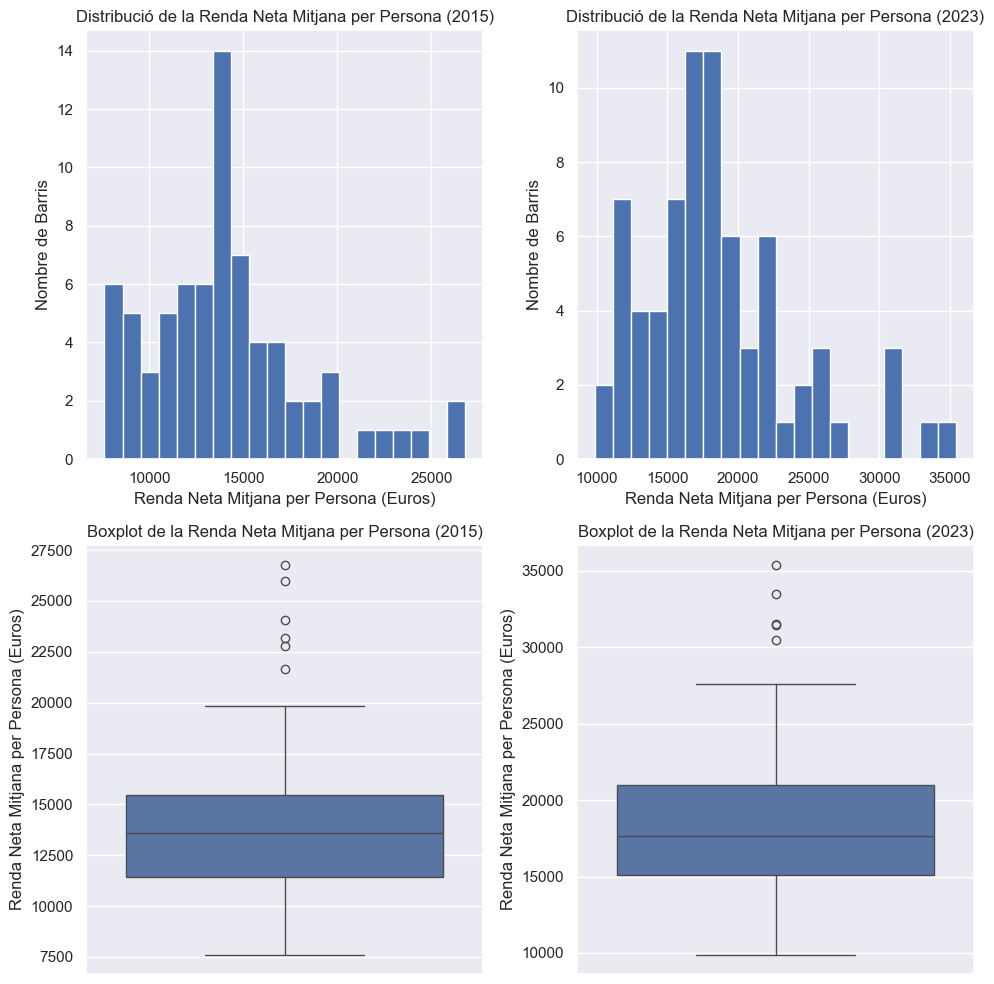

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Distr Renda 2015
axes[0, 0].hist(df_renda_15_grouped["Import_Euros"], bins=20)
axes[0, 0].set_title("Distribució de la Renda Neta Mitjana per Persona (2015)")
axes[0, 0].set_xlabel("Renda Neta Mitjana per Persona (Euros)")
axes[0, 0].set_ylabel("Nombre de Barris")

# Distr Renda 2023
axes[0, 1].hist(df_renda_23_grouped["Import_Euros"], bins=20)
axes[0, 1].set_title("Distribució de la Renda Neta Mitjana per Persona (2023)")
axes[0, 1].set_xlabel("Renda Neta Mitjana per Persona (Euros)")
axes[0, 1].set_ylabel("Nombre de Barris")

# Boxplot Renda 2015
sns.boxplot(y=df_renda_15_grouped["Import_Euros"], ax=axes[1, 0])
axes[1, 0].set_title("Boxplot de la Renda Neta Mitjana per Persona (2015)")
axes[1, 0].set_ylabel("Renda Neta Mitjana per Persona (Euros)")

# Boxplot Renda 2023
sns.boxplot(y=df_renda_23_grouped["Import_Euros"], ax=axes[1, 1])
axes[1, 1].set_title("Boxplot de la Renda Neta Mitjana per Persona (2023)")
axes[1, 1].set_ylabel("Renda Neta Mitjana per Persona (Euros)")

plt.tight_layout()
plt.savefig("../results/figs/distribucio_renda.png")
plt.show()

**Observacions:**
- s

## Index Gini

### 2023

In [24]:
df_gini_23_raw = pd.read_csv("../data/raw/renda/2023_atles_renda_index_gini.csv")
df_gini_23_raw.head()

,Any,Codi_Districte,Nom_Districte,Codi_Barri,Nom_Barri,Seccio_Censal,Index_Gini
0,2023,1,Ciutat Vella,1,el Raval,1,34.2
1,2023,1,Ciutat Vella,1,el Raval,2,34.7
2,2023,1,Ciutat Vella,1,el Raval,3,35.9
3,2023,1,Ciutat Vella,1,el Raval,4,35.9
4,2023,1,Ciutat Vella,1,el Raval,5,36.2


In [25]:
df_gini_23_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Any             1068 non-null   int64  
 1   Codi_Districte  1068 non-null   int64  
 2   Nom_Districte   1068 non-null   object 
 3   Codi_Barri      1068 non-null   int64  
 4   Nom_Barri       1068 non-null   object 
 5   Seccio_Censal   1068 non-null   int64  
 6   Index_Gini      1068 non-null   float64
dtypes: float64(1), int64(4), object(2)
memory usage: 58.5+ KB


**Observacions:**
- No s'observen valors nuls ni "..".
- Index Gini Float és correcte.

In [26]:
# Agrupem per barri i calculem mitjana
df_gini_23_grouped = df_gini_23_raw.groupby("Codi_Barri").agg({"Index_Gini": "mean"}).reset_index()
df_gini_23_grouped.head()

,Codi_Barri,Index_Gini
0,1,33.795238
1,2,39.266667
2,3,32.809091
3,4,36.769231
4,5,31.890000


### 2015

In [27]:
df_gini_15_raw = pd.read_csv("../data/raw/renda/2015_atles_renda_index_gini.csv")
df_gini_15_raw.head()

,Any,Codi_Districte,Nom_Districte,Codi_Barri,Nom_Barri,Seccio_Censal,Index_Gini
0,2015,1,Ciutat Vella,1,el Raval,1,36.5
1,2015,1,Ciutat Vella,1,el Raval,2,40.4
2,2015,1,Ciutat Vella,1,el Raval,3,38.4
3,2015,1,Ciutat Vella,1,el Raval,4,40.4
4,2015,1,Ciutat Vella,1,el Raval,5,38.6


In [28]:
df_gini_15_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Any             1068 non-null   int64  
 1   Codi_Districte  1068 non-null   int64  
 2   Nom_Districte   1068 non-null   object 
 3   Codi_Barri      1068 non-null   int64  
 4   Nom_Barri       1068 non-null   object 
 5   Seccio_Censal   1068 non-null   int64  
 6   Index_Gini      1058 non-null   float64
dtypes: float64(1), int64(4), object(2)
memory usage: 58.5+ KB


**Observacions:**
- No s'observen valors nuls ni "..".
- Index Gini Float és correcte.

In [29]:
df_gini_15_grouped = df_gini_15_raw.groupby("Codi_Barri").agg({"Index_Gini": "mean"}).reset_index()
df_gini_15_grouped.head()

,Codi_Barri,Index_Gini
0,1,36.338095
1,2,41.087500
2,3,34.954545
3,4,39.515385
4,5,34.020000


### EDA

In [30]:
df_gini_23_grouped.describe()

,Codi_Barri,Index_Gini
count,73.000000,73.000000
mean,37.000000,31.159606
std,21.217131,3.587312
min,1.000000,24.760000
25%,19.000000,28.700000
50%,37.000000,30.660000
75%,55.000000,32.690000
max,73.000000,41.385714


In [31]:
df_gini_15_grouped.describe()

,Codi_Barri,Index_Gini
count,73.000000,73.000000
mean,37.000000,33.191980
std,21.217131,3.221096
min,1.000000,26.140000
25%,19.000000,31.033333
50%,37.000000,32.800000
75%,55.000000,34.802500
max,73.000000,41.087500


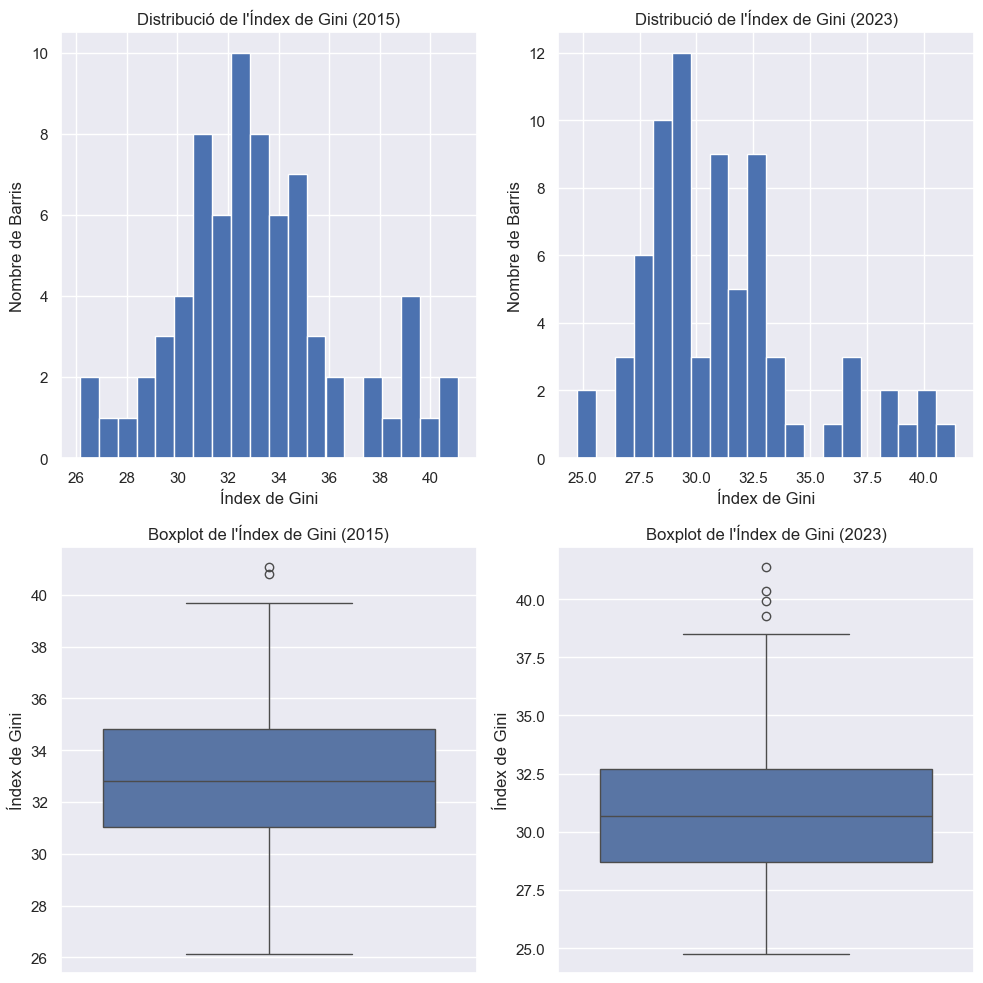

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Distr Renda 2015
axes[0, 0].hist(df_gini_15_grouped["Index_Gini"], bins=20)
axes[0, 0].set_title("Distribució de l'Índex de Gini (2015)")
axes[0, 0].set_xlabel("Índex de Gini")
axes[0, 0].set_ylabel("Nombre de Barris")

# Distr Renda 2023
axes[0, 1].hist(df_gini_23_grouped["Index_Gini"], bins=20)
axes[0, 1].set_title("Distribució de l'Índex de Gini (2023)")
axes[0, 1].set_xlabel("Índex de Gini")
axes[0, 1].set_ylabel("Nombre de Barris")

# Boxplot Renda 2015
sns.boxplot(y=df_gini_15_grouped["Index_Gini"], ax=axes[1, 0])
axes[1, 0].set_title("Boxplot de l'Índex de Gini (2015)")
axes[1, 0].set_ylabel("Índex de Gini")

# Boxplot Renda 2023
sns.boxplot(y=df_gini_23_grouped["Index_Gini"], ax=axes[1, 1])
axes[1, 1].set_title("Boxplot de l'Índex de Gini (2023)")
axes[1, 1].set_ylabel("Índex de Gini")
plt.tight_layout()
plt.savefig("../results/figs/distribucio_gini.png")
plt.show()

**observacions:**
- s

## Agregacions

In [45]:
df_econs = dim_barris.copy()
df_econs.rename({"codi_barri": "Codi_Barri"}, axis = 1, inplace=True)

df_econs_15 = df_econs[["Codi_Barri"]].merge(df_renda_15_grouped, on="Codi_Barri", how="left")\
    .merge(df_gini_15_grouped, on="Codi_Barri", how="left")
df_econs_15.head()

,Codi_Barri,Import_Euros,Index_Gini
0,1,8507.809524,36.338095
1,2,11447.444444,41.087500
2,3,10818.818182,34.954545
3,4,11689.000000,39.515385
4,5,15441.500000,34.020000


In [47]:
df_econs = dim_barris.copy()
df_econs.rename({"codi_barri": "Codi_Barri"}, axis = 1, inplace=True)

df_econs_23 = df_econs[["Codi_Barri"]].merge(df_renda_23_grouped, on="Codi_Barri", how="left")\
    .merge(df_gini_23_grouped, on="Codi_Barri", how="left")
df_econs_23.head()

,Codi_Barri,Import_Euros,Index_Gini
0,1,11917.476190,33.795238
1,2,16013.222222,39.266667
2,3,15359.818182,32.809091
3,4,16621.153846,36.769231
4,5,20418.800000,31.890000


In [48]:
# Neteja noms columnes
df_econs_15_clean = neteja_noms_columnes(df_econs_15)
df_econs_23_clean = neteja_noms_columnes(df_econs_23)

In [50]:
df_econs_15_clean.to_csv("../data/processed/df_economiques_15.csv", index=False)
df_econs_23_clean.to_csv("../data/processed/df_economiques_23.csv", index=False)

# Dataset Final
Aquest serà el dataset de dades econòmiques que utilitzarem per al modelatge. En aquest cas hem de calcular deltes de Gini i Renda.

In [55]:
# Creuem els dos anys
df_merged = df_econs_15_clean.merge(df_econs_23_clean, on="codi_barri", suffixes=("_2015", "_2023"), how="outer")
df_merged.head()

,codi_barri,import_euros_2015,index_gini_2015,import_euros_2023,index_gini_2023
0,1,8507.809524,36.338095,11917.476190,33.795238
1,2,11447.444444,41.087500,16013.222222,39.266667
2,3,10818.818182,34.954545,15359.818182,32.809091
3,4,11689.000000,39.515385,16621.153846,36.769231
4,5,15441.500000,34.020000,20418.800000,31.890000


In [57]:
# Calculem deltes
df_merged["delta_renda"] = (df_merged["import_euros_2023"] - df_merged["import_euros_2015"]) / df_merged["import_euros_2015"]
df_merged["delta_gini"] = (df_merged["index_gini_2023"] - df_merged["index_gini_2015"]) / df_merged["index_gini_2015"]
df_merged.head()

,codi_barri,import_euros_2015,index_gini_2015,import_euros_2023,index_gini_2023,delta_renda,delta_gini
0,1,8507.809524,36.338095,11917.476190,33.795238,0.400769,-0.069978
1,2,11447.444444,41.087500,16013.222222,39.266667,0.398847,-0.044316
2,3,10818.818182,34.954545,15359.818182,32.809091,0.419732,-0.061378
3,4,11689.000000,39.515385,16621.153846,36.769231,0.421948,-0.069496
4,5,15441.500000,34.020000,20418.800000,31.890000,0.322333,-0.062610


Per al modelatge, utilitzarem les variacions calculades i el valor absolut del darrer any. D'aquesta manera es podran capturar dinàmiques i estat actual dels barris.

In [58]:
# Seleccionem columnes desitjades
df_final = df_merged[["codi_barri", "delta_renda", "delta_gini", "import_euros_2023", "index_gini_2023"]]\
    .rename(columns={"import_euros_2023": "renda_2023", "index_gini_2023": "gini_2023"})
df_final.head()

,codi_barri,delta_renda,delta_gini,renda_2023,gini_2023
0,1,0.400769,-0.069978,11917.476190,33.795238
1,2,0.398847,-0.044316,16013.222222,39.266667
2,3,0.419732,-0.061378,15359.818182,32.809091
3,4,0.421948,-0.069496,16621.153846,36.769231
4,5,0.322333,-0.062610,20418.800000,31.890000


In [61]:
df_final.to_csv("../data/final/df_economiques_final.csv", index=False)

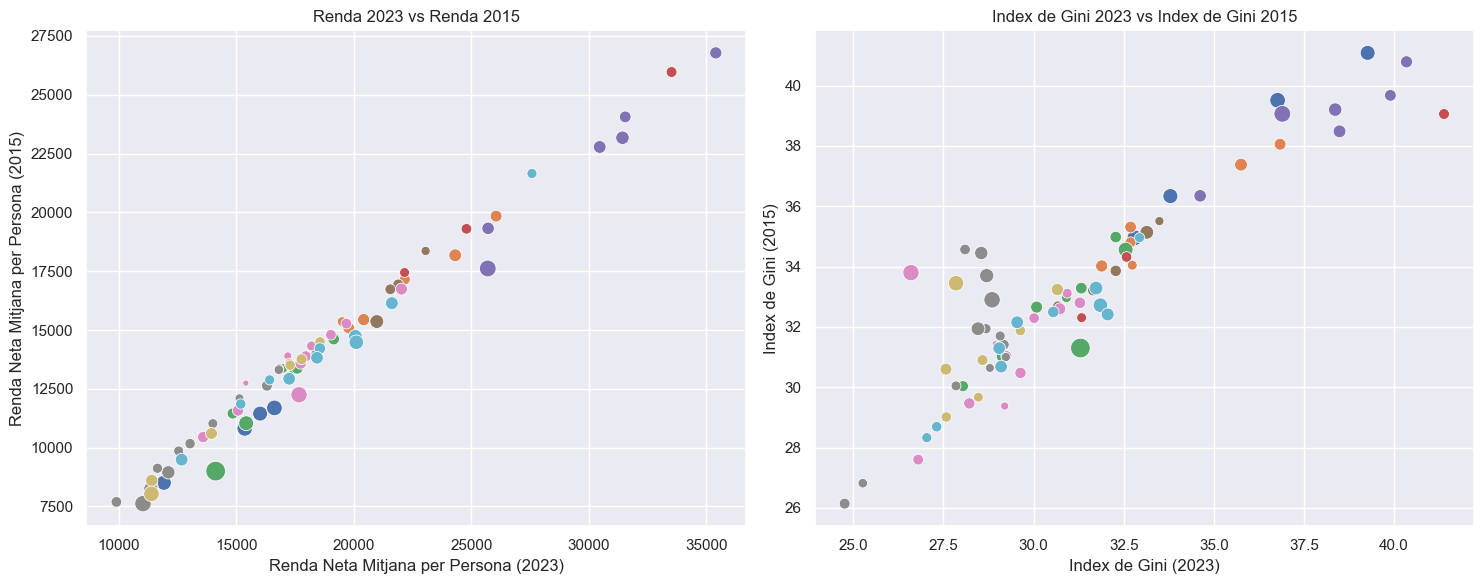

In [87]:
## EDA
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df_merged_noms = df_merged.merge(dim_barris[["codi_barri", "nom_barri", "nom_districte"]], left_on="codi_barri", right_on="codi_barri", how="left")

# Renda 2023 vs Renda 2015
sns.scatterplot(data=df_merged_noms, 
                x="import_euros_2023", 
                y="import_euros_2015", 
                hue="nom_districte",  
                size="delta_renda",
                sizes = (20, 200),
                ax=axes[0], 
                legend = False)
axes[0].set_title("Renda 2023 vs Renda 2015")
axes[0].set_xlabel("Renda Neta Mitjana per Persona (2023)")
axes[0].set_ylabel("Renda Neta Mitjana per Persona (2015)")

sns.scatterplot(data=df_merged_noms, 
                x="index_gini_2023", 
                y="index_gini_2015", 
                hue="nom_districte",  
                size="delta_renda",
                sizes = (20, 200),
                ax=axes[1], 
                legend = False)

axes[1].set_title("Index de Gini 2023 vs Index de Gini 2015")
axes[1].set_xlabel("Index de Gini (2023)")
axes[1].set_ylabel("Index de Gini (2015)")

plt.tight_layout()
plt.savefig("../results/figs/renda_gini_scatter.png")
plt.show()